# Plotting Utilities Notebook

This notebook is the notebook version of `utils.py`, adapted to this repo layout. It reads result `.npz` files from the project root, renders figures inline, and saves the main panel figure to `figures/mmd_flow.pdf`.

In [7]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results" / "nonparametric"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_FIGURE = FIGURES_DIR / "mmd_flow.pdf"

plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, mathrsfs, amssymb}')


FIGSIZE = (6, 4)
DPI = 100
TITLE_SIZE = 24
LABEL_SIZE = 38
TICK_SIZE = 38
LEGEND_SIZE = 36
MARKER_SIZE = 7
COMPARISON_SCATTER_SIZE = 28
LINE_WIDTH = 3.0
TITLE_PAD = 5
INLINE_LEGEND_SIZE = 18
COLORS = {"mmd": "#d95f02", "smmd": "#1b9e77", "svgd": "#7570b3"}

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DejaVu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
FOUR_PANEL_RC = {
    **LOCAL_PLOT_RC,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 14,
    "lines.markersize": 3.5,
}
plt.rcParams.update(BASE_PLOT_RC)
ROOT, RESULTS_DIR, OUTPUT_FIGURE

(PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/nonparametric'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/mmd_flow.pdf'))

In [8]:
def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _sample_target_mog(num_samples, seed=0, radius=2.0, std=0.2, k=8):
    rng = np.random.default_rng(seed)
    angles = 2.0 * np.pi * np.arange(k, dtype=np.float64) / k
    means = np.stack(
        [radius * np.cos(angles), radius * np.sin(angles)],
        axis=1,
    )
    component_ids = rng.integers(0, k, size=num_samples)
    return means[component_ids] + rng.normal(scale=std, size=(num_samples, 2))


def _sample_initial_particles(num_particles, seed=0, d=2):
    rng = np.random.default_rng(seed)
    return rng.normal(loc=0.0, scale=1.0, size=(num_particles, d)).astype(np.float64)


def _draw_initial_particles_plot(
    ax,
    initial_samples,
    xlim=None,
    ylim=None,
    show_legend=True,
):
    initial_samples = np.asarray(initial_samples, dtype=float)
    ax.scatter(
        initial_samples[:, 0] / 3.0,
        initial_samples[:, 1] / 3.0,
        s=COMPARISON_SCATTER_SIZE,
        facecolors="none",
        edgecolors="#444444",
        linewidths=0.9,
        alpha=0.9,
        label="Initial",
    )
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.15, linewidth=0.8)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if show_legend:
        ax.legend(loc="lower left", fontsize=INLINE_LEGEND_SIZE, frameon=True, facecolor="white", framealpha=0.9)


def _comparison_plot_limits(target_samples, fixed_samples, adaptive_samples, initial_samples=None):
    all_samples = [target_samples, fixed_samples, adaptive_samples]
    if initial_samples is not None:
        all_samples.append(np.asarray(initial_samples, dtype=float))
    all_samples = np.vstack(all_samples)
    mins = all_samples.min(axis=0)
    maxs = all_samples.max(axis=0)
    center = 0.5 * (mins + maxs)
    span = np.max(maxs - mins)
    half_width = 0.55 * span
    x_min, x_max = center[0] - half_width, center[0] + half_width
    y_min, y_max = center[1] - half_width, center[1] + half_width

    return x_min, x_max, y_min, y_max


def _draw_comparison_plot(
    ax,
    target_samples,
    fixed_samples,
    adaptive_samples,
    initial_samples=None,
    show_legend=True,
):
    x_min, x_max, y_min, y_max = _comparison_plot_limits(
        target_samples,
        fixed_samples,
        adaptive_samples,
        initial_samples=initial_samples,
    )
    ax.scatter(
        fixed_samples[:, 0],
        fixed_samples[:, 1],
        s=COMPARISON_SCATTER_SIZE,
        c=COLORS["mmd"],
        alpha=0.55,
        edgecolors="none",
        label="Fixed",
    )
    ax.scatter(
        adaptive_samples[:, 0],
        adaptive_samples[:, 1],
        s=COMPARISON_SCATTER_SIZE,
        c=COLORS["smmd"],
        alpha=0.45,
        edgecolors="none",
        label="Adaptive",
    )
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.15, linewidth=0.8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if show_legend:
        ax.legend(loc="lower left", fontsize=INLINE_LEGEND_SIZE, frameon=True, facecolor="white", framealpha=0.9)


def _mmd_band_from_mean_se(mean, se=None, factor=2.0, se_scale=1.0):
    mean = np.asarray(mean, dtype=float)
    mmd = np.sqrt(np.maximum(factor * mean, 0.0))
    if se is None:
        return mmd, None
    se = se_scale * np.asarray(se, dtype=float)
    lower = np.sqrt(np.maximum(factor * (mean - se), 0.0))
    upper = np.sqrt(np.maximum(factor * (mean + se), 0.0))
    return mmd, (lower, upper)


def _mmd_band_from_histories(histories, factor=2.0, se_scale=1.0):
    histories = np.asarray(histories, dtype=float)
    mmd_histories = np.sqrt(np.maximum(factor * histories, 0.0))
    mmd = np.nanmean(mmd_histories, axis=0)
    valid_counts = np.maximum(np.sum(~np.isnan(mmd_histories), axis=0), 1)
    se = se_scale * np.nanstd(mmd_histories, axis=0) / np.sqrt(valid_counts)
    lower = np.maximum(mmd - se, 0.0)
    upper = mmd + se
    return mmd, (lower, upper)


def _draw_mmd_vs_n_plot(
    ax,
    ns,
    fixed_mmd,
    adaptive_mmd,
    fixed_band=None,
    adaptive_band=None,
    show_legend=True,
    show_ylabel=True,
):
    ns = np.asarray(ns, dtype=float)
    fixed_mmd = np.asarray(fixed_mmd, dtype=float)
    adaptive_mmd = np.asarray(adaptive_mmd, dtype=float)
    if fixed_band is not None:
        ax.fill_between(ns, fixed_band[0], fixed_band[1], color=COLORS["mmd"], alpha=0.22, linewidth=0)
    if adaptive_band is not None:
        ax.fill_between(ns, adaptive_band[0], adaptive_band[1], color=COLORS["smmd"], alpha=0.22, linewidth=0)
    ax.plot(ns, fixed_mmd, marker="o", color=COLORS["mmd"], label="Fixed", zorder=3)
    ax.plot(ns, adaptive_mmd, marker="o", color=COLORS["smmd"], label="Adaptive", zorder=3)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Particle Number $N$")
    if show_ylabel:
        ax.set_ylabel(r"$\mathrm{MMD}_{\ell_\infty}(\mathbb{P}, \mathbb{Q})$", labelpad=4)
    ax.grid(True, which="major", alpha=0.15, linewidth=0.8)
    if show_legend:
        ax.legend(loc="lower left", fontsize=INLINE_LEGEND_SIZE, frameon=True, facecolor="white", framealpha=0.9)



def _draw_mmd_vs_iteration_plot(
    ax,
    fixed_mmd,
    adaptive_mmd,
    fixed_steps=None,
    adaptive_steps=None,
    fixed_band=None,
    adaptive_band=None,
    show_legend=True,
    show_ylabel=True,
):
    fixed_mmd = np.asarray(fixed_mmd, dtype=float)
    adaptive_mmd = np.asarray(adaptive_mmd, dtype=float)
    if fixed_steps is None:
        fixed_steps = np.arange(1, fixed_mmd.shape[0] + 1, dtype=float)
    if adaptive_steps is None:
        adaptive_steps = np.arange(1, adaptive_mmd.shape[0] + 1, dtype=float)
    fixed_steps = np.asarray(fixed_steps, dtype=float)
    adaptive_steps = np.asarray(adaptive_steps, dtype=float)
    if fixed_band is not None:
        ax.fill_between(fixed_steps, fixed_band[0], fixed_band[1], color=COLORS["mmd"], alpha=0.22, linewidth=0)
    if adaptive_band is not None:
        ax.fill_between(adaptive_steps, adaptive_band[0], adaptive_band[1], color=COLORS["smmd"], alpha=0.22, linewidth=0)
    ax.plot(fixed_steps, fixed_mmd, color=COLORS["mmd"], label="Fixed", zorder=3)
    ax.plot(adaptive_steps, adaptive_mmd, color=COLORS["smmd"], label="Adaptive", zorder=3)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    if show_ylabel:
        ax.set_ylabel(r"$\mathrm{MMD}_{\ell_\infty}(\mathbb{P}, \mathbb{Q})$", labelpad=4)
    ax.set_ylim(1e-2, 0.3)
    # ax.set_title("MMD vs Iteration", pad=TITLE_PAD)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    if show_legend:
        ax.legend(loc="best", fontsize=INLINE_LEGEND_SIZE, frameon=True, facecolor="white", framealpha=0.9)


def _draw_lhs_rhs_plot(ax, steps, lhs, rhs, show_legend=True, show_ylabel=True):
    steps = np.asarray(steps, dtype=float)
    lhs = np.asarray(lhs, dtype=float)
    rhs = np.asarray(rhs, dtype=float)
    ax.plot(steps, lhs, color="#D62728", label="LHS")
    ax.plot(steps, rhs, color="#111111", label="RHS")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    # ax.set_title("LHS vs RHS", pad=TITLE_PAD)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    if show_legend:
        ax.legend(loc="lower left", fontsize=INLINE_LEGEND_SIZE * 1.5, frameon=True, facecolor="white", framealpha=0.9)


def make_comparison_plot(
    target_samples,
    fixed_samples,
    adaptive_samples,
    fixed_mmd,
    adaptive_mmd,
):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        _draw_comparison_plot(ax, target_samples, fixed_samples, adaptive_samples)
        fig.tight_layout()
        return fig


def make_mmd_vs_n_plot(ns, fixed_mmd, adaptive_mmd, fixed_band=None, adaptive_band=None):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        _draw_mmd_vs_n_plot(ax, ns, fixed_mmd, adaptive_mmd, fixed_band=fixed_band, adaptive_band=adaptive_band)
        fig.tight_layout()
        return fig


def make_mmd_vs_iteration_plot(
    fixed_mmd,
    adaptive_mmd,
    fixed_steps=None,
    adaptive_steps=None,
    fixed_band=None,
    adaptive_band=None,
):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        _draw_mmd_vs_iteration_plot(
            ax,
            fixed_mmd,
            adaptive_mmd,
            fixed_steps=fixed_steps,
            adaptive_steps=adaptive_steps,
            fixed_band=fixed_band,
            adaptive_band=adaptive_band,
        )
        fig.tight_layout()
        return fig


def make_lhs_rhs_plot(steps, lhs, rhs):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
        _draw_lhs_rhs_plot(ax, steps, lhs, rhs)
        fig.tight_layout()
        return fig


def _mmd_iteration_from_npz_data(data, se_scale=1.0):
    if "fixed_hists" in data and "adapt_hists" in data:
        fixed_mmd, fixed_band = _mmd_band_from_histories(data["fixed_hists"], se_scale=se_scale)
        adaptive_mmd, adaptive_band = _mmd_band_from_histories(data["adapt_hists"], se_scale=se_scale)
        fixed_steps = np.arange(1, fixed_mmd.shape[0] + 1, dtype=float)
        adaptive_steps = np.arange(1, adaptive_mmd.shape[0] + 1, dtype=float)
        return fixed_steps, fixed_mmd, fixed_band, adaptive_steps, adaptive_mmd, adaptive_band

    if "fixed_histories" in data and "adapt_histories" in data:
        fixed_mmd, fixed_band = _mmd_band_from_histories(data["fixed_histories"], se_scale=se_scale)
        adaptive_mmd, adaptive_band = _mmd_band_from_histories(data["adapt_histories"], se_scale=se_scale)
        fixed_steps = np.asarray(data.get("fixed_history_steps", np.arange(1, fixed_mmd.shape[0] + 1)), dtype=float)
        adaptive_steps = np.asarray(data.get("adapt_history_steps", np.arange(1, adaptive_mmd.shape[0] + 1)), dtype=float)
        return fixed_steps, fixed_mmd, fixed_band, adaptive_steps, adaptive_mmd, adaptive_band

    fixed_steps = np.asarray(data["fixed_history_steps"], dtype=float)
    adaptive_steps = np.asarray(data["adapt_history_steps"], dtype=float)
    fixed_se = data["fixed_history_se"] if "fixed_history_se" in data else None
    adaptive_se = data["adapt_history_se"] if "adapt_history_se" in data else None
    fixed_mmd, fixed_band = _mmd_band_from_mean_se(data["fixed_history_mean"], fixed_se, se_scale=se_scale)
    adaptive_mmd, adaptive_band = _mmd_band_from_mean_se(data["adapt_history_mean"], adaptive_se, se_scale=se_scale)
    return fixed_steps, fixed_mmd, fixed_band, adaptive_steps, adaptive_mmd, adaptive_band


def make_mmd_vs_iteration_plot_from_npz(npz_path, se_scale=1.0):
    data = _load_npz_dict(npz_path)
    fixed_steps, fixed_mmd, fixed_band, adaptive_steps, adaptive_mmd, adaptive_band = _mmd_iteration_from_npz_data(
        data,
        se_scale=se_scale,
    )
    return make_mmd_vs_iteration_plot(
        fixed_mmd,
        adaptive_mmd,
        fixed_steps=fixed_steps,
        adaptive_steps=adaptive_steps,
        fixed_band=fixed_band,
        adaptive_band=adaptive_band,
    )


def make_lhs_rhs_plot_from_npz(npz_path):
    data = _load_npz_dict(npz_path)
    steps = np.asarray(data["last_adapt_checkpoint_steps"], dtype=float)
    lhs = np.asarray(data["last_adapt_lhs"], dtype=float)
    rhs = np.asarray(data["last_adapt_rhs"], dtype=float)
    return make_lhs_rhs_plot(steps, lhs, rhs)


def make_comparison_plot_from_npz(
    npz_path,
    num_target_samples=5000,
    target_seed=0,
    radius=2.0,
    std=0.2,
    k=8,
):
    data = _load_npz_dict(npz_path)
    target_samples = _sample_target_mog(
        num_samples=num_target_samples,
        seed=target_seed,
        radius=radius,
        std=std,
        k=k,
    )
    fixed_samples = np.asarray(data["last_fixed_particles"], dtype=float)
    adaptive_samples = np.asarray(data["last_adapt_particles"], dtype=float)
    fixed_mmd = np.sqrt(max(2.0 * float(data["fixed_mean"]), 0.0))
    adaptive_mmd = np.sqrt(max(2.0 * float(data["adapt_mean"]), 0.0))
    return make_comparison_plot(
        target_samples=target_samples,
        fixed_samples=fixed_samples,
        adaptive_samples=adaptive_samples,
        fixed_mmd=fixed_mmd,
        adaptive_mmd=adaptive_mmd,
    )


def make_mmd_vs_n_plot_from_npz(npz_paths, ns, se_scale=1.0):
    fixed_mmd = []
    adaptive_mmd = []
    fixed_lower = []
    fixed_upper = []
    adaptive_lower = []
    adaptive_upper = []
    have_fixed_band = True
    have_adaptive_band = True

    for npz_path in npz_paths:
        data = _load_npz_dict(npz_path)
        fixed_value, fixed_band = _mmd_band_from_mean_se(
            data["fixed_mean"],
            data["fixed_se"] if "fixed_se" in data else None,
            se_scale=se_scale,
        )
        adaptive_value, adaptive_band = _mmd_band_from_mean_se(
            data["adapt_mean"],
            data["adapt_se"] if "adapt_se" in data else None,
            se_scale=se_scale,
        )
        fixed_mmd.append(float(fixed_value))
        adaptive_mmd.append(float(adaptive_value))
        if fixed_band is None:
            have_fixed_band = False
        else:
            fixed_lower.append(float(fixed_band[0]))
            fixed_upper.append(float(fixed_band[1]))
        if adaptive_band is None:
            have_adaptive_band = False
        else:
            adaptive_lower.append(float(adaptive_band[0]))
            adaptive_upper.append(float(adaptive_band[1]))

    fixed_band = (np.asarray(fixed_lower), np.asarray(fixed_upper)) if have_fixed_band else None
    adaptive_band = (np.asarray(adaptive_lower), np.asarray(adaptive_upper)) if have_adaptive_band else None

    return make_mmd_vs_n_plot(
        ns=np.asarray(ns, dtype=float),
        fixed_mmd=np.asarray(fixed_mmd, dtype=float),
        adaptive_mmd=np.asarray(adaptive_mmd, dtype=float),
        fixed_band=fixed_band,
        adaptive_band=adaptive_band,
    )


def make_four_panel_figure(
    comparison_npz,
    mmd_vs_n_npz_paths,
    mmd_vs_n_ns,
    mmd_vs_iteration_npz,
    lhs_rhs_npz,
    se_scale=1.0,
):
    comparison_data = _load_npz_dict(comparison_npz)
    target_samples = _sample_target_mog(num_samples=5000, seed=0, radius=2.0, std=0.2, k=8)
    fixed_samples = np.asarray(comparison_data["last_fixed_particles"], dtype=float)
    adaptive_samples = np.asarray(comparison_data["last_adapt_particles"], dtype=float)
    comparison_seed = int(np.asarray(comparison_data["fixed_finals"]).shape[0] - 1)
    initial_samples = _sample_initial_particles(fixed_samples.shape[0], seed=comparison_seed, d=fixed_samples.shape[1])

    mmd_vs_n_fixed = []
    mmd_vs_n_adaptive = []
    mmd_vs_n_fixed_lower = []
    mmd_vs_n_fixed_upper = []
    mmd_vs_n_adaptive_lower = []
    mmd_vs_n_adaptive_upper = []
    have_mmd_vs_n_fixed_band = True
    have_mmd_vs_n_adaptive_band = True
    for npz_path in mmd_vs_n_npz_paths:
        data = _load_npz_dict(npz_path)
        fixed_value, fixed_band = _mmd_band_from_mean_se(
            data["fixed_mean"],
            data["fixed_se"] if "fixed_se" in data else None,
            se_scale=se_scale,
        )
        adaptive_value, adaptive_band = _mmd_band_from_mean_se(
            data["adapt_mean"],
            data["adapt_se"] if "adapt_se" in data else None,
            se_scale=se_scale,
        )
        mmd_vs_n_fixed.append(float(fixed_value))
        mmd_vs_n_adaptive.append(float(adaptive_value))
        if fixed_band is None:
            have_mmd_vs_n_fixed_band = False
        else:
            mmd_vs_n_fixed_lower.append(float(fixed_band[0]))
            mmd_vs_n_fixed_upper.append(float(fixed_band[1]))
        if adaptive_band is None:
            have_mmd_vs_n_adaptive_band = False
        else:
            mmd_vs_n_adaptive_lower.append(float(adaptive_band[0]))
            mmd_vs_n_adaptive_upper.append(float(adaptive_band[1]))
    mmd_vs_n_fixed = np.asarray(mmd_vs_n_fixed, dtype=float)
    mmd_vs_n_adaptive = np.asarray(mmd_vs_n_adaptive, dtype=float)
    mmd_vs_n_ns = np.asarray(mmd_vs_n_ns, dtype=float)
    mmd_vs_n_fixed_band = (
        (np.asarray(mmd_vs_n_fixed_lower), np.asarray(mmd_vs_n_fixed_upper))
        if have_mmd_vs_n_fixed_band
        else None
    )
    mmd_vs_n_adaptive_band = (
        (np.asarray(mmd_vs_n_adaptive_lower), np.asarray(mmd_vs_n_adaptive_upper))
        if have_mmd_vs_n_adaptive_band
        else None
    )

    iteration_data = _load_npz_dict(mmd_vs_iteration_npz)
    (
        iteration_fixed_steps,
        iteration_fixed_mmd,
        iteration_fixed_band,
        iteration_adaptive_steps,
        iteration_adaptive_mmd,
        iteration_adaptive_band,
    ) = _mmd_iteration_from_npz_data(iteration_data, se_scale=se_scale)

    lhs_rhs_data = _load_npz_dict(lhs_rhs_npz)
    lhs_rhs_steps = np.asarray(lhs_rhs_data["last_adapt_checkpoint_steps"], dtype=float)
    lhs_values = np.asarray(lhs_rhs_data["last_adapt_lhs"], dtype=float)
    rhs_values = np.asarray(lhs_rhs_data["last_adapt_rhs"], dtype=float)
    with plt.rc_context(FOUR_PANEL_RC):
        fig = plt.figure(figsize=(25 / 1.2, 5), dpi=100, constrained_layout=True)
        gs = fig.add_gridspec(
            2,
            4,
            width_ratios=[1.0, 1.0, 1.0, 1.0],
            height_ratios=[1.0, 1.0],
            wspace=0.05,
            hspace=-0.05,
        )
        ax_initial = fig.add_subplot(gs[:, 0])
        ax_comparison = fig.add_subplot(gs[:, 1])
        ax_mmd_iter = fig.add_subplot(gs[0, 2])
        ax_mmd_n = fig.add_subplot(gs[1, 2])
        ax_lhs_rhs = fig.add_subplot(gs[:, 3])

        comparison_xlim, comparison_ylim = _comparison_plot_limits(
            target_samples,
            fixed_samples,
            adaptive_samples,
        )[:2], _comparison_plot_limits(
            target_samples,
            fixed_samples,
            adaptive_samples,
        )[2:]

        _draw_initial_particles_plot(
            ax_initial,
            initial_samples,
            xlim=comparison_xlim,
            ylim=comparison_ylim,
            show_legend=True,
        )
        _draw_comparison_plot(
            ax_comparison,
            target_samples,
            fixed_samples,
            adaptive_samples,
            show_legend=True,
        )
        _draw_mmd_vs_n_plot(
            ax_mmd_n,
            mmd_vs_n_ns,
            mmd_vs_n_fixed,
            mmd_vs_n_adaptive,
            fixed_band=mmd_vs_n_fixed_band,
            adaptive_band=mmd_vs_n_adaptive_band,
            show_legend=True,
        )
        _draw_mmd_vs_iteration_plot(
            ax_mmd_iter,
            iteration_fixed_mmd,
            iteration_adaptive_mmd,
            fixed_steps=iteration_fixed_steps,
            adaptive_steps=iteration_adaptive_steps,
            fixed_band=iteration_fixed_band,
            adaptive_band=iteration_adaptive_band,
            show_legend=True,
        )
        _draw_lhs_rhs_plot(
            ax_lhs_rhs,
            lhs_rhs_steps,
            lhs_values,
            rhs_values,
        )
        return fig


## Local file setup

These defaults match the files that already exist in this repo. The iteration-history and `lhs/rhs` inputs are optional because they are not currently present in this workspace.

In [9]:
comparison_npz = RESULTS_DIR / "results_n100f.npz"
mmd_vs_n_npz_paths = [
    RESULTS_DIR / "results_n10f.npz",
    RESULTS_DIR / "results_n30f.npz",
    RESULTS_DIR / "results_n100f.npz",
    RESULTS_DIR / "results_n300f.npz",
]
mmd_vs_n_ns = [10, 30, 100, 300]
mmd_vs_iteration_npz = RESULTS_DIR / "results_n100f.npz"
lhs_rhs_npz = RESULTS_DIR / "results_n100f.npz"

{
    "comparison_npz": comparison_npz,
    "mmd_vs_n_npz_paths": mmd_vs_n_npz_paths,
    "mmd_vs_iteration_npz": mmd_vs_iteration_npz,
    "lhs_rhs_npz": lhs_rhs_npz,
}

{'comparison_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/nonparametric/results_n100f.npz'),
 'mmd_vs_n_npz_paths': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/nonparametric/results_n10f.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/nonparametric/results_n30f.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/nonparametric/results_n100f.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/nonparametric/results_n300f.npz')],
 'mmd_vs_iteration_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/nonparametric/results_n100f.npz'),
 'lhs_rhs_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/nonparametric/results_n100f.npz')}

In [10]:
available_inputs = {
    "comparison_npz": comparison_npz.exists(),
    "mmd_vs_n_npz_paths": [path.exists() for path in mmd_vs_n_npz_paths],
    "mmd_vs_iteration_npz": mmd_vs_iteration_npz.exists(),
    "lhs_rhs_npz": lhs_rhs_npz.exists(),
}
available_inputs

{'comparison_npz': True,
 'mmd_vs_n_npz_paths': [True, True, True, True],
 'mmd_vs_iteration_npz': True,
 'lhs_rhs_npz': True}

Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/mmd_flow.pdf


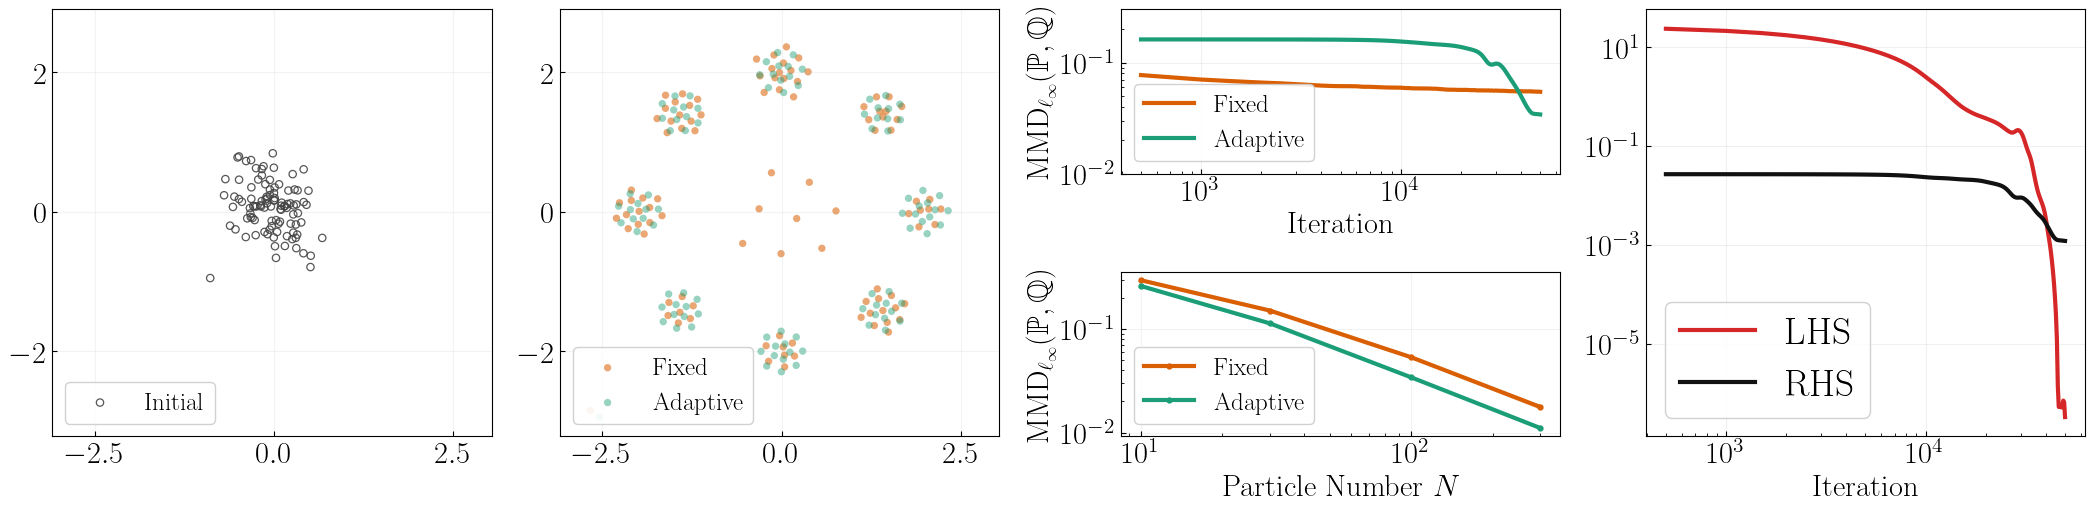

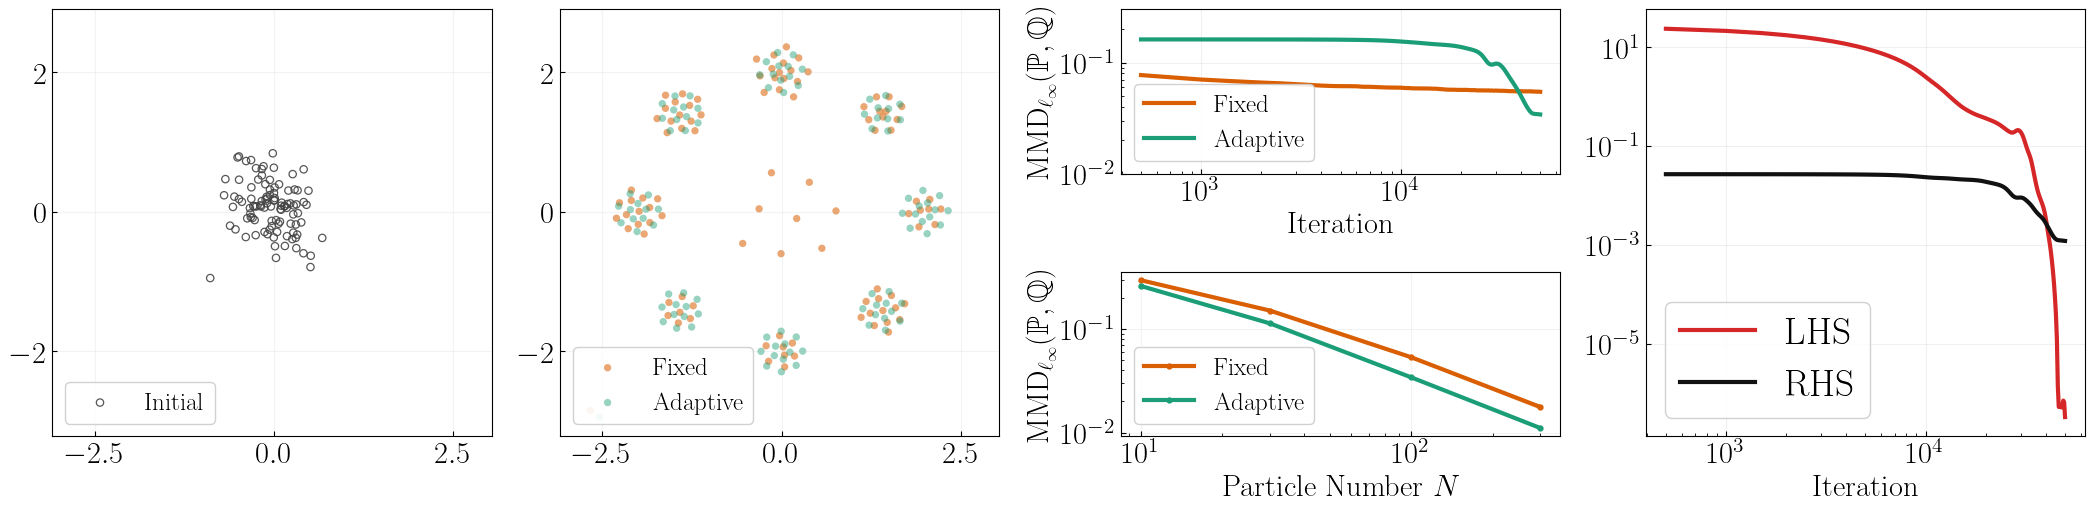

In [11]:
required_inputs = [comparison_npz, *mmd_vs_n_npz_paths, mmd_vs_iteration_npz, lhs_rhs_npz]
missing_inputs = [path for path in required_inputs if not path.exists()]

if not missing_inputs:
    fig = make_four_panel_figure(
        comparison_npz=comparison_npz,
        mmd_vs_n_npz_paths=mmd_vs_n_npz_paths,
        mmd_vs_n_ns=mmd_vs_n_ns,
        mmd_vs_iteration_npz=mmd_vs_iteration_npz,
        lhs_rhs_npz=lhs_rhs_npz,
        se_scale=1.96,
    )
    fig.savefig(OUTPUT_FIGURE, bbox_inches="tight")
    print(f"Saved figure to {OUTPUT_FIGURE}")
    display(fig)
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )


In [12]:
# Figures render inline in the previous cell and are also saved to OUTPUT_FIGURE.